# Evaluating all existing submissions

In [2]:
import numpy as np
import pandas as pd
import glob
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error

In [3]:
Y_train = pd.read_csv('../data/processed/Y_train.csv').squeeze()

with open('../data/output/cv_scores.json', 'r') as f:
    log = json.load(f)

leaderboard = pd.DataFrame(log).sort_values('cv_rmse_mean').reset_index(drop=True)

# ── Load all OOF files ────────────────────────────────────────
oof_files = glob.glob('../data/output/oof/*.npy')

oof_results = {}
for f in oof_files:
    name = os.path.basename(f).replace('.npy', '')   # e.g. oof_lgbm
    oof  = np.load(f)
    rmse = root_mean_squared_error(Y_train, oof)
    oof_results[name] = {
        'oof'  : oof,
        'rmse' : rmse
    }
    print(f"  ✅ {name:<20} OOF RMSE: {rmse:.5f}")

  ✅ oof_round1_quickRF   OOF RMSE: 0.14091
  ✅ oof_round2_optunaRF  OOF RMSE: 0.13851
  ✅ oof_round3_lightGBM  OOF RMSE: 0.13283
  ✅ oof_round4_linreg_lasso OOF RMSE: 0.16254
  ✅ oof_round5_linreg_lasso_fe-linear OOF RMSE: 0.13932
  ✅ oof_round5_linreg_lasso_fe-trees OOF RMSE: 0.13932
  ✅ oof_round6_lightGBM_fe_linear-200 OOF RMSE: 0.13188
  ✅ oof_round6_lightGBM_fe_trees OOF RMSE: 0.13151
  ✅ oof_round7_xgb_fe_linear OOF RMSE: 0.12630
  ✅ oof_round9_CatBoost  OOF RMSE: 0.12530


In [4]:
print("=" * 65)
print("📋 CV LEADERBOARD")
print("=" * 65)
print(leaderboard[['model', 'cv_rmse_mean', 'cv_rmse_std', 'notes']].to_string(index=False))

📋 CV LEADERBOARD
                        model  cv_rmse_mean  cv_rmse_std                                                                                              notes
         round7_xgb_fe_linear       0.11761      0.01103                                                                                xgb using fe_linear
         round7_xgb_fe_linear       0.11801      0.01013                                                                                xgb using fe_linear
          round7_xgb_fe_trees       0.11824      0.00982                                                                                 xgb using fe_trees
                   round7_xgb       0.11841      0.01213                                                xgb using regular features (no feature engineering)
         round7_xgb_fe_linear       0.11860      0.01048                                                                                xgb using fe_linear
              round9_CatBoost       0.11941    

In [5]:
oof_df = pd.DataFrame([
    {
        'model'    : name.replace('oof_', ''),
        'oof_rmse' : res['rmse']
    }
    for name, res in oof_results.items()
]).sort_values('oof_rmse').reset_index(drop=True)

print("\n" + "=" * 45)
print("📋 OOF LEADERBOARD")
print("=" * 45)
print(oof_df.to_string(index=False))


📋 OOF LEADERBOARD
                        model  oof_rmse
              round9_CatBoost  0.125299
         round7_xgb_fe_linear  0.126298
     round6_lightGBM_fe_trees  0.131513
round6_lightGBM_fe_linear-200  0.131879
              round3_lightGBM  0.132829
              round2_optunaRF  0.138506
round5_linreg_lasso_fe-linear  0.139317
 round5_linreg_lasso_fe-trees  0.139317
               round1_quickRF  0.140905
          round4_linreg_lasso  0.162545


C:\Users\Chyi\AppData\Local\Temp\ipykernel_14260\2654930256.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


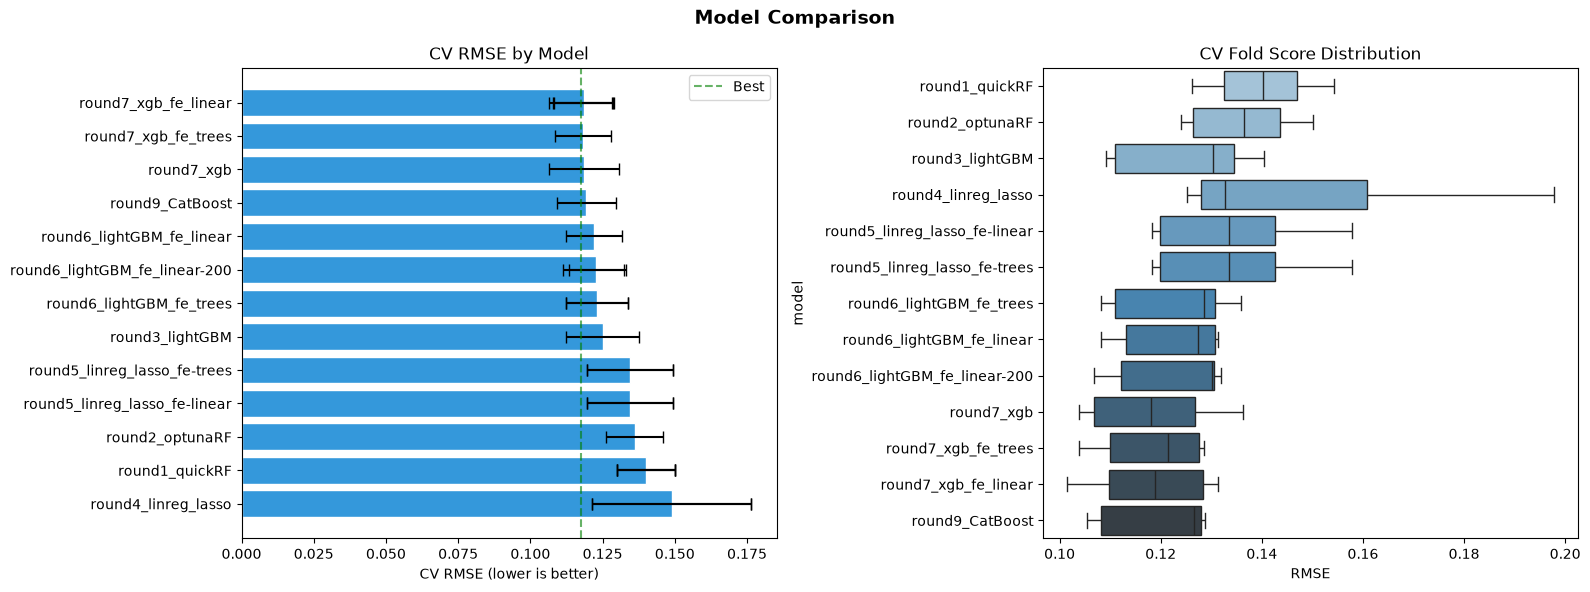

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

# ── Bar chart with error bars ────────────────────────────────
colors = ['#2ecc71' if i == 0 else '#3498db'
          for i in range(len(leaderboard))]

axes[0].barh(
    leaderboard['model'],
    leaderboard['cv_rmse_mean'],
    xerr=leaderboard['cv_rmse_std'],
    color=colors,
    edgecolor='white',
    capsize=4
)
axes[0].set_xlabel('CV RMSE (lower is better)')
axes[0].set_title('CV RMSE by Model')
axes[0].axvline(leaderboard['cv_rmse_mean'].min(), color='green',
                linestyle='--', alpha=0.6, label='Best')
axes[0].legend()
axes[0].invert_yaxis()

# ── CV fold scores per model ─────────────────────────────────
fold_data = []
for entry in log:
    for i, score in enumerate(entry['cv_scores']):
        fold_data.append({
            'model' : entry['model'],
            'fold'  : f"Fold {i+1}",
            'rmse'  : score
        })

fold_df = pd.DataFrame(fold_data)

sns.boxplot(
    data=fold_df,
    x='rmse',
    y='model',
    ax=axes[1],
    palette='Blues_d'
)
axes[1].set_xlabel('RMSE')
axes[1].set_title('CV Fold Score Distribution')

plt.tight_layout()
plt.savefig('../plots/model_leaderboard.png', dpi=150)
plt.show()

C:\Users\Chyi\AppData\Local\Temp\ipykernel_14260\2331759315.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


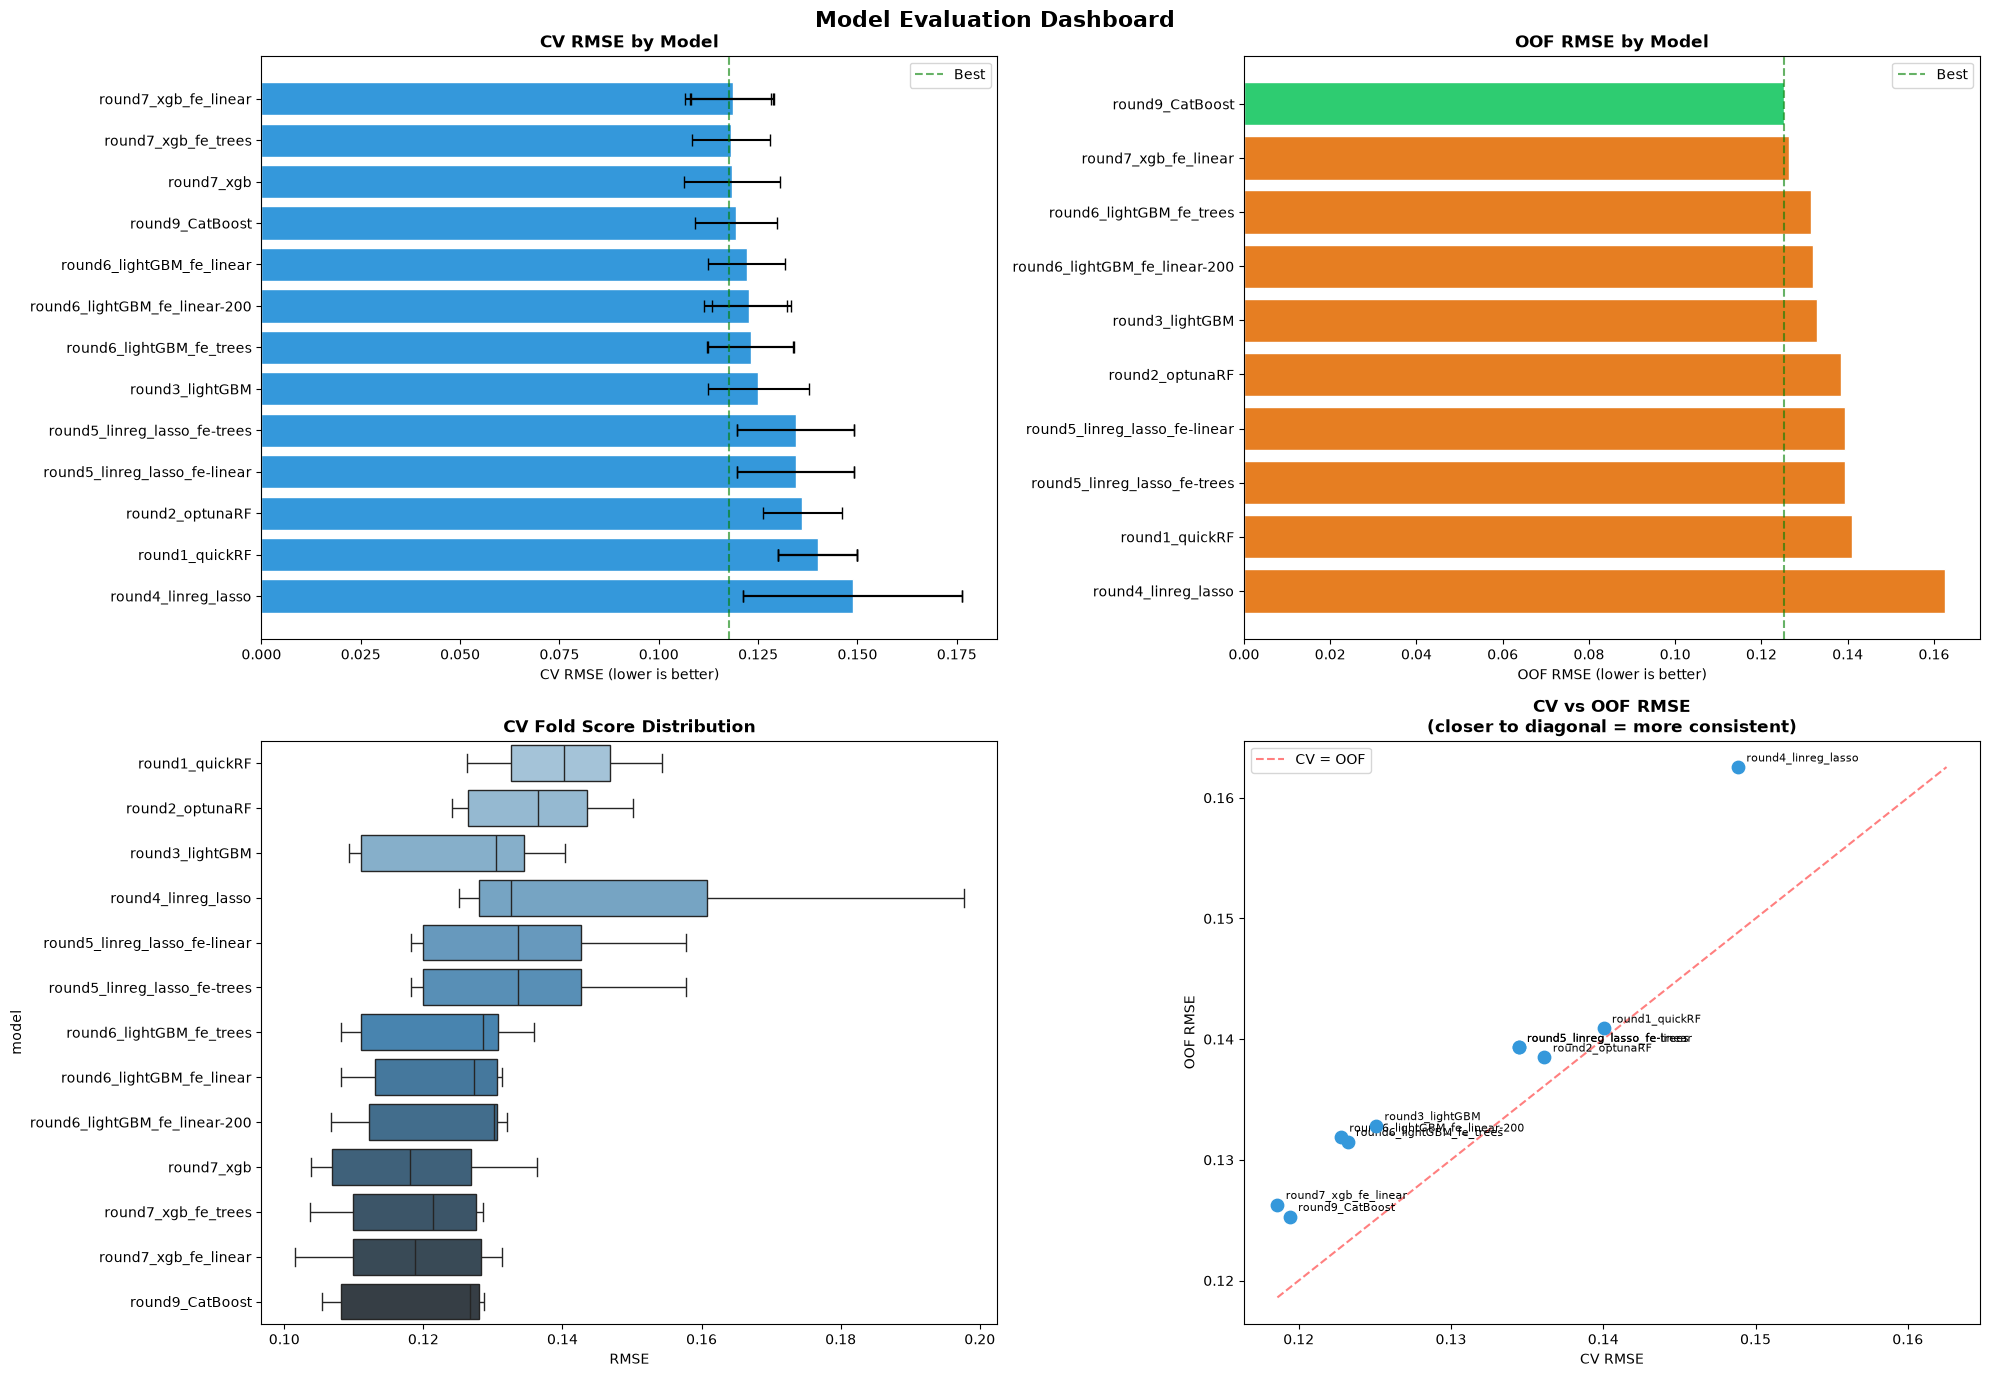

In [7]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Model Evaluation Dashboard', fontsize=16, fontweight='bold')

# ── Layout: 2x2 grid ─────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)   # CV RMSE bar
ax2 = fig.add_subplot(2, 2, 2)   # OOF RMSE bar
ax3 = fig.add_subplot(2, 2, 3)   # CV fold distribution
ax4 = fig.add_subplot(2, 2, 4)   # CV vs OOF scatter

# ── Plot 1: CV RMSE bar ───────────────────────────────────────
colors_cv = ['#2ecc71' if i == 0 else '#3498db'
             for i in range(len(leaderboard))]

ax1.barh(
    leaderboard['model'],
    leaderboard['cv_rmse_mean'],
    xerr=leaderboard['cv_rmse_std'],
    color=colors_cv,
    edgecolor='white',
    capsize=4
)
ax1.axvline(leaderboard['cv_rmse_mean'].min(), color='green',
            linestyle='--', alpha=0.6, label='Best')
ax1.set_xlabel('CV RMSE (lower is better)')
ax1.set_title('CV RMSE by Model', fontweight='bold')
ax1.legend()
ax1.invert_yaxis()

# ── Plot 2: OOF RMSE bar ──────────────────────────────────────
colors_oof = ['#2ecc71' if i == 0 else '#e67e22'
              for i in range(len(oof_df))]

ax2.barh(
    oof_df['model'],
    oof_df['oof_rmse'],
    color=colors_oof,
    edgecolor='white',
)
ax2.axvline(oof_df['oof_rmse'].min(), color='green',
            linestyle='--', alpha=0.6, label='Best')
ax2.set_xlabel('OOF RMSE (lower is better)')
ax2.set_title('OOF RMSE by Model', fontweight='bold')
ax2.legend()
ax2.invert_yaxis()

# ── Plot 3: CV fold distribution ──────────────────────────────
fold_data = []
for entry in log:
    for i, score in enumerate(entry['cv_scores']):
        fold_data.append({
            'model': entry['model'],
            'fold' : f"Fold {i+1}",
            'rmse' : score
        })

fold_df = pd.DataFrame(fold_data)

sns.boxplot(
    data=fold_df,
    x='rmse',
    y='model',
    ax=ax3,
    palette='Blues_d'
)
ax3.set_xlabel('RMSE')
ax3.set_title('CV Fold Score Distribution', fontweight='bold')

# ── Plot 4: CV vs OOF scatter ─────────────────────────────────
# Match models that appear in both
cv_dict  = dict(zip(leaderboard['model'], leaderboard['cv_rmse_mean']))
oof_dict = {name.replace('oof_', ''): res['rmse']
            for name, res in oof_results.items()}

common   = set(cv_dict.keys()) & set(oof_dict.keys())

cv_vals  = [cv_dict[m]  for m in common]
oof_vals = [oof_dict[m] for m in common]
labels   = list(common)

ax4.scatter(cv_vals, oof_vals, color='#3498db', s=80, zorder=5)

# Label each point
for label, cv, oof in zip(labels, cv_vals, oof_vals):
    ax4.annotate(label, (cv, oof),
                 textcoords='offset points',
                 xytext=(6, 4),
                 fontsize=8)

# Diagonal line — if CV == OOF they sit on this line
all_vals = cv_vals + oof_vals
ax4.plot([min(all_vals), max(all_vals)],
         [min(all_vals), max(all_vals)],
         'r--', alpha=0.5, label='CV = OOF')
ax4.set_xlabel('CV RMSE')
ax4.set_ylabel('OOF RMSE')
ax4.set_title('CV vs OOF RMSE\n(closer to diagonal = more consistent)',
              fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.savefig('../plots/model_evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

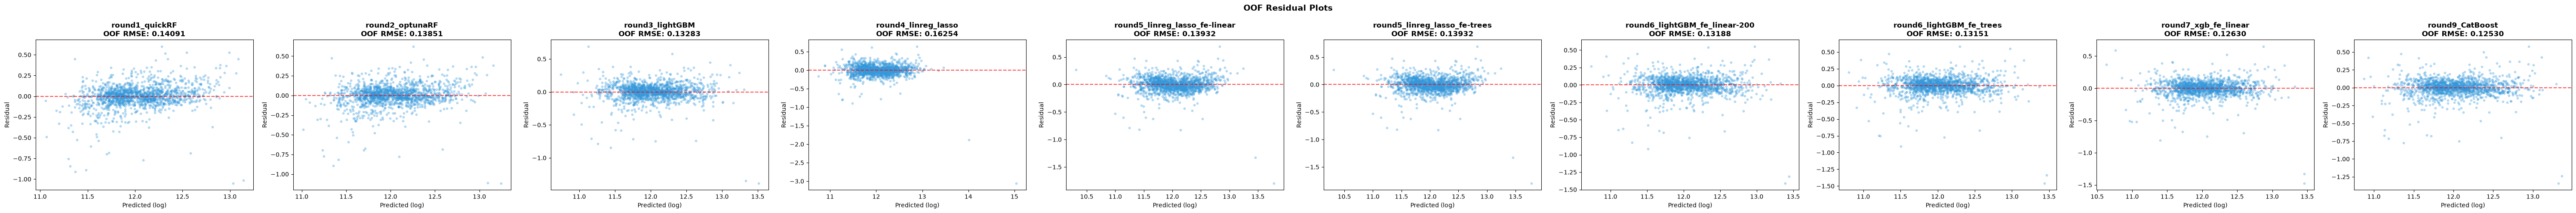

In [8]:
# Visualise where each model is making its biggest errors
fig, axes = plt.subplots(1, len(oof_results), figsize=(6 * len(oof_results), 5))

if len(oof_results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, oof_results.items()):
    residuals = Y_train - res['oof']

    ax.scatter(res['oof'], residuals, alpha=0.3, s=10, color='#3498db')
    ax.axhline(0, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel('Predicted (log)')
    ax.set_ylabel('Residual')
    ax.set_title(f"{name.replace('oof_', '')}\nOOF RMSE: {res['rmse']:.5f}",
                 fontweight='bold')

plt.suptitle('OOF Residual Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/oof_residuals.png', dpi=150)
plt.show()